# EE 467 Lab 8: Malware Detection with Transformer Models
Welcome to lab 8 (final lab) of EE 467! In this lab, we're going to detect malware activities with Transformer Natural Language Models. We will work with the ADFA-LD dataset, which consists of system call logs for both benign and malicious activities. You will learn to preprocess these logs into text form, pass them into BERT model for feature extraction, visualize the distribution of features and perform classification on top of these features.

## Lab Dependencies
As usual, we'll install all dependencies needed for this lab: `torch`, `transformers`, `scikit-learn` and other libraries. If you're not running this notebook on Google Colab, you should choose one of the two ways to install PyTorch depending on whether Nvidia GPU and CUDA are available on your machine:

In [1]:
# Install PyTorch with `pip`
# (Refer to https://pytorch.org for installation instructions for Nvidia GPUs)
%pip install torch

# ... or with `conda` (not officially supported)
#%conda install conda-forge::pytorch     # (without GPU support)
#%conda install conda-forge::pytorch-gpu # (with GPU support)

# Install other libraries needed for this lab
%pip install accelerate matplotlib numpy scikit-learn transformers

In [2]:
!tar -xvf adfa-ld.tar.xz #<---- To Unzip the dataset in Colab

Streaming output truncated to the last 5000 lines.
ADFA-LD/Validation_Data_Master/UVD-1448.txt
ADFA-LD/Validation_Data_Master/UVD-0030.txt
ADFA-LD/Validation_Data_Master/UVD-4256.txt
ADFA-LD/Validation_Data_Master/UVD-3539.txt
ADFA-LD/Validation_Data_Master/UVD-2627.txt
ADFA-LD/Validation_Data_Master/UVD-4242.txt
ADFA-LD/Validation_Data_Master/UVD-2633.txt
ADFA-LD/Validation_Data_Master/UVD-0024.txt
ADFA-LD/Validation_Data_Master/UVD-0742.txt
ADFA-LD/Validation_Data_Master/UVD-2155.txt
ADFA-LD/Validation_Data_Master/UVD-0805.txt
ADFA-LD/Validation_Data_Master/UVD-2974.txt
ADFA-LD/Validation_Data_Master/UVD-2960.txt
ADFA-LD/Validation_Data_Master/UVD-0811.txt
ADFA-LD/Validation_Data_Master/UVD-0839.txt
ADFA-LD/Validation_Data_Master/UVD-2948.txt
ADFA-LD/Validation_Data_Master/UVD-2790.txt
ADFA-LD/Validation_Data_Master/UVD-1299.txt
ADFA-LD/Validation_Data_Master/UVD-0187.txt
ADFA-LD/Validation_Data_Master/UVD-0193.txt
ADFA-LD/Validation_Data_Master/UVD-2784.txt
ADFA-LD/Validation_Data_M

## Data Loading and Preprocessing
We start by loading the ADFA-LD dataset, which consists of system call logs for both benign and malicious activities. They are stored under the `ADFA-LD` folder at different locations:

* The `Training_Data_Master` folder contains system call logs for benign activities, and each log is recorded in a single `.txt` file.
* The `Attack_Data_Master` folder contains system call logs for malicious activities. There are multiple sub-folders named in the format of `<attack_type>_<i>`, where `attack_type` is the type of attack and `i` is the `i`-th run for collecting such logs. Again, each log is recorded in a single `.txt` file.

In [3]:
import glob

ATTACK_TYPES = {
    "add_user": "Adduser",
    "hydra_ftp": "Hydra_FTP",
    "hydra_ssh": "Hydra_SSH",
    "java_meterpreter": "Java_Meterpreter",
    "meterpreter": "Meterpreter",
    "web_shell": "Web_Shell"
}

def load_syscall_logs(log_path_pattern):
    """ Select system call logs by file name pattern and load selected logs. """
    logs = {}

    # Get all log files by pattern
    log_paths = glob.glob(log_path_pattern)
    # Load content of each log file
    for log_path in log_paths:
        with open(log_path) as f:
            logs[log_path] = " ".join(f.read().split())

    return logs

all_logs = {}

# Load benign logs
all_logs["benign"] = load_syscall_logs("ADFA-LD/Training_Data_Master/*.txt")
# Load malicious logs
for attack_type, raw_type in ATTACK_TYPES.items():
    all_logs[attack_type] = load_syscall_logs(f"ADFA-LD/Attack_Data_Master/{raw_type}_*/*.txt")

Now, let's preview one of the system call logs to see how they look like:

In [4]:
next(iter(all_logs["benign"].values()))

'6 11 45 33 192 33 5 197 192 6 33 5 3 197 192 192 6 33 5 3 197 192 192 192 6 33 5 3 197 192 192 192 6 33 5 3 197 192 192 6 33 5 3 197 192 192 6 33 5 3 197 192 192 192 6 192 192 243 125 125 125 125 125 125 125 125 91 258 311 240 240 174 174 175 191 122 174 45 45 254 42 221 221 255 255 5 3 6 102 221 102 102 255 255 255 256 265 102 255 255 256 265 3 255 255 255 265 6 6 6'

Our example system call log contains a series of integers, and it turns out that these integers are system call numbers. Before we can process these logs with Transformer-based Language Models, we need to convert them into proper texts. To do that, we'll load the system call name and number table from `ADFA-LD/syscall-table.csv`, and build a number to name mapping for log conversion:

In [5]:
syscall_map = {}

with open("ADFA-LD/syscall-table.csv") as f:
    for line in f.readlines():
        line = line.strip()
        if not line:
            continue

        # Read raw system call name and system call number
        raw_syscall_name, syscall_number = line.split(",")
        # Remove raw name prefixes
        syscall_name = raw_syscall_name.removeprefix("__NR_").removeprefix("__NR3264_")
        syscall_number = int(syscall_number)

        syscall_map[syscall_number] = syscall_name

The built system call number to name mapping should look like this:

In [6]:
syscall_map

{0: 'io_setup',
 1: 'io_destroy',
 2: 'io_submit',
 3: 'io_cancel',
 4: 'io_getevents',
 5: 'setxattr',
 6: 'lsetxattr',
 7: 'fsetxattr',
 8: 'getxattr',
 9: 'lgetxattr',
 10: 'fgetxattr',
 11: 'listxattr',
 12: 'llistxattr',
 13: 'flistxattr',
 14: 'removexattr',
 15: 'lremovexattr',
 16: 'fremovexattr',
 17: 'getcwd',
 18: 'lookup_dcookie',
 19: 'eventfd2',
 20: 'epoll_create1',
 21: 'epoll_ctl',
 22: 'epoll_pwait',
 23: 'dup',
 24: 'dup3',
 25: 'fcntl',
 26: 'inotify_init1',
 27: 'inotify_add_watch',
 28: 'inotify_rm_watch',
 29: 'ioctl',
 30: 'ioprio_set',
 31: 'ioprio_get',
 32: 'flock',
 33: 'mknodat',
 34: 'mkdirat',
 35: 'unlinkat',
 36: 'symlinkat',
 37: 'linkat',
 38: 'renameat',
 39: 'umount2',
 40: 'mount',
 41: 'pivot_root',
 42: 'nfsservctl',
 43: 'statfs',
 44: 'fstatfs',
 45: 'truncate',
 46: 'ftruncate',
 47: 'fallocate',
 48: 'faccessat',
 49: 'chdir',
 50: 'fchdir',
 51: 'chroot',
 52: 'fchmod',
 53: 'fchmodat',
 54: 'fchownat',
 55: 'fchown',
 56: 'openat',
 57: 'cl

With the system call number-to-name mapping, we preprocess the raw system call logs into textual form. We explore two representations:

* **Simple textual logs**: each system call number is replaced by its name from the mapping. Numbers without a known name are kept as-is.
* **Concise textual logs**: on top of the simple representation, consecutive repetitions of the same system call are collapsed into `<name> * <count>` (e.g., `read read read` → `read * 3`).

Both representations are saved alongside their labels. The concise format produces significantly shorter sequences, which can help BERT tokenize more of each log within its 512-token limit.


In [7]:
text_logs = []
concise_logs = []
labels = []

for i, (log_type, logs) in enumerate(all_logs.items()):
    for log_path, raw_log in logs.items():
        # [ TODO ]
        # 1. Convert raw log into an array of system call numbers.
        syscalls = [int(x) for x in raw_log.strip().split()]
        syscalls_names = [syscall_map[num] for num in syscalls if num in syscall_map]
        # 2. Create a simple textual log from the raw log, by replacing system call numbers with names,
        #    and save it as `text_log`.
        text_log = " ".join(syscalls_names)
        # 3. Create a concise textual log from the raw log, by replacing system call numbers with names
        #    and consolidate repeated system calls into a single name and an occurrence count as shown above.
        #    Name the processed log as `concise_log`.
        concise_parts = []
        prev = None
        count = 0

        for name in syscalls_names:
            if name == prev:
                count += 1
            else:
              if prev is not None:
                concise_parts.append(f"{prev}:{count}")
              prev = name
              count = 1

        if prev is not None:
          concise_parts.append(f"{prev}:{count}")

        concise_log = " ".join(concise_parts)

        text_logs.append(text_log)
        concise_logs.append(concise_log)
        # Label: 0 = benign, 1..6 = individual attack types (follows all_logs insertion order)
        labels.append(i)


After preprocessing, we can now compare a simple and a concise log preprocessed from the same raw log:

In [8]:
print("Simple log:", text_logs[1])
print("Concise log:", concise_logs[1])

Simple log: lsetxattr lsetxattr read lsetxattr execve lsetxattr execve read shmctl shmctl listxattr truncate mknodat semtimedop mknodat setxattr shmdt semtimedop lsetxattr mknodat setxattr io_cancel shmdt semtimedop semtimedop lsetxattr mknodat setxattr io_cancel shmdt semtimedop semtimedop lsetxattr mknodat setxattr io_cancel shmdt semtimedop semtimedop semtimedop lsetxattr mknodat setxattr io_cancel shmdt semtimedop semtimedop semtimedop lsetxattr mknodat setxattr io_cancel shmdt semtimedop semtimedop lsetxattr mknodat setxattr io_cancel shmdt semtimedop semtimedop semtimedop lsetxattr mknodat setxattr io_cancel shmdt semtimedop semtimedop lsetxattr mknodat setxattr io_cancel shmdt semtimedop semtimedop semtimedop lsetxattr mknodat setxattr io_cancel shmdt semtimedop semtimedop semtimedop lsetxattr mknodat setxattr io_cancel shmdt semtimedop semtimedop semtimedop lsetxattr mknodat setxattr io_cancel shmdt semtimedop semtimedop semtimedop lsetxattr mknodat setxattr io_cancel shmdt sem

## Feature Extraction
Now that we have preprocessed raw system call logs into textual logs, it's time to extract features for these logs using Transformer-based Language Models. Here, we'll use [BERT](https://huggingface.co/docs/transformers/model_doc/bert), one of the most famous encoder-based Transformer-style model. We start feature extraction by loading the tokenizer and model of [`bert-base-uncased`](https://huggingface.co/google-bert/bert-base-uncased), one of the BERT variant, onto the proper device (Nvidia or Apple GPU, or CPU as fallback).

In [9]:
import warnings

import torch
from torch.cuda import is_available as is_cuda_available
from torch.backends.mps import is_available as is_mps_available
from transformers import BertTokenizer, BertModel

# Prefer Nvidia or Apple GPU backends
if is_cuda_available():
    model_device = "cuda"
elif is_mps_available():
    model_device = "mps"
# Fallback to CPU
else:
    warnings.warn("running BERT model with CPU - inference speed may be slower")
    model_device = "cpu"

# Model data type
model_dtype = torch.bfloat16
#model_dtype = torch.float16

# Initialize BERT / RoBERTa tokenizer and model on target device
BERT_MODEL_NAME = "bert-base-uncased"

tokenizer = BertTokenizer.from_pretrained(BERT_MODEL_NAME)
model = BertModel.from_pretrained(
    BERT_MODEL_NAME, device_map=model_device, torch_dtype=model_dtype, attn_implementation="sdpa"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Next, we perform the actual feature extraction by passing all processed logs through the BERT model in four steps:

1. Create a [`torch.utils.data.DataLoader`](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html) to iterate over logs in mini-batches, which is more memory-efficient than processing everything at once.
2. Tokenize each batch with the BERT tokenizer, padding and truncating to 512 tokens.
3. Run a forward pass through the BERT model (inference) and extract the hidden state of the `[CLS]` token — this special token summarizes the entire sequence and serves as the embedding.
4. Collect and concatenate all embeddings into a single NumPy array.

In [11]:
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm

# @torch.inference_mode() disables gradient tracking,
# which is safer and faster for inference-only code
@torch.inference_mode()
def make_bert_embeds(logs, batch_size=256, max_len=512):
    embeds = []

    # [ TODO ]
    # 1. Create a PyTorch data loader that iterates over `logs` with given `batch_size`
    loader = DataLoader(logs, batch_size=batch_size)

    for batch_logs in tqdm(loader):
        # 2. Pass `batch_logs` to BERT tokenizer for tokenization and input preparation.
        #    The tokenizer should return PyTorch tensors and truncate sequences to `max_len`.
        inputs = tokenizer(
            batch_logs,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_len
        )
        # Move inputs to the target device
        # inputs = inputs.to(model_device)
        inputs = {k: v.to(model_device) for k, v in inputs.items()}

        # 3. Forward inputs through BERT model.
        outputs = model(**inputs)
        # 4. Save feature embeddings, which are the features for the first token in every sequence.
        embeds.append(outputs.last_hidden_state[:, 0].cpu())

    # Concatenate all batches into a single (N, hidden_dim) array
    embeds = torch.cat(embeds).float().numpy()
    return embeds

text_embeds = make_bert_embeds(text_logs)
concise_embeds = make_bert_embeds(concise_logs)

100%|██████████| 7/7 [01:15<00:00, 10.79s/it]


## Dimensionality Reduction and Feature Visualization
The BERT embeddings live in a 768-dimensional space — too high to visualize directly. We use [t-SNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) to project both the textual and concise embeddings down to 3 dimensions, preserving local structure so that samples with similar features appear close together in the plot.


In [12]:
from sklearn.manifold import TSNE

RAND_STATE = 42

# Perform t-SNE on textual embeddings
tsne_text = TSNE(n_components=3, random_state=RAND_STATE)
tsne_feats_text = tsne_text.fit_transform(text_embeds)

# Perform t-SNE on concise embeddings
tsne_concise = TSNE(n_components=3, random_state=RAND_STATE)
tsne_feats_concise = tsne_concise.fit_transform(concise_embeds)


And then draw the reduced-dimension features in a 3D space with `matplotlib`:

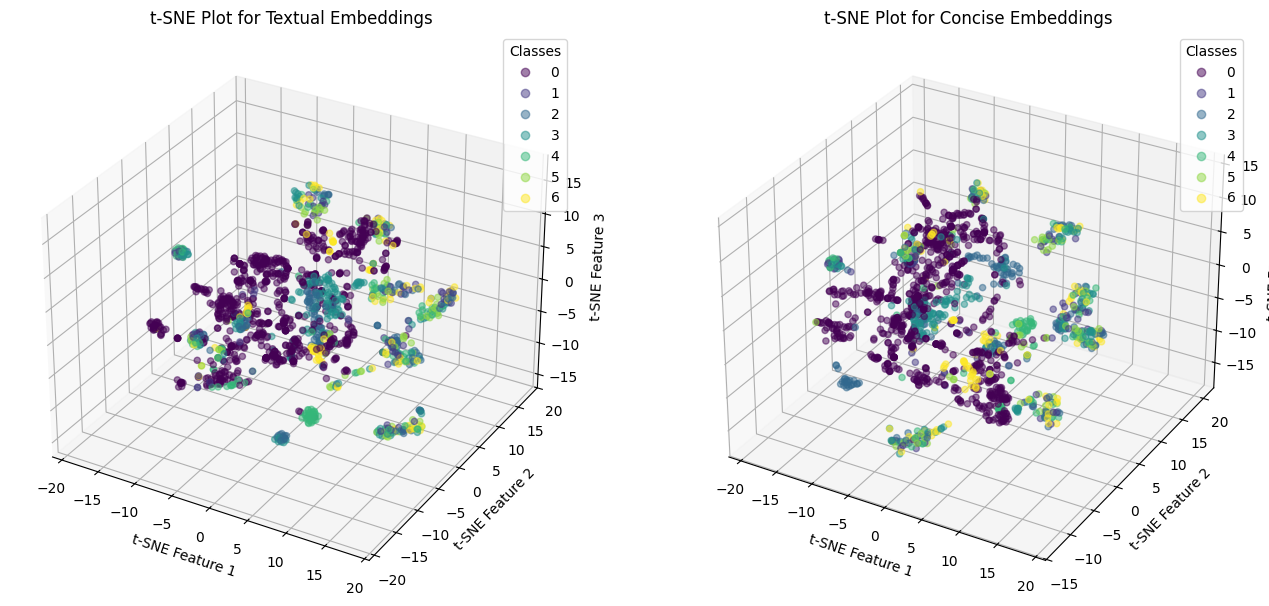

In [13]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

def plot_feats(ax, feats, labels, feat_name):
    # Make a 3D scatter plot
    scatter = ax.scatter(feats[:, 0], feats[:, 1], feats[:, 2], c=labels, cmap='viridis', alpha=0.5)
    # Add legend
    ax.legend(*scatter.legend_elements(), title="Classes")

    # Set title and axis labels
    ax.set_title("t-SNE Plot for "+feat_name)
    ax.set_xlabel("t-SNE Feature 1")
    ax.set_ylabel("t-SNE Feature 2")
    ax.set_zlabel("t-SNE Feature 3")

fig = plt.figure(figsize=(16, 8))
plot_feats(fig.add_subplot(1, 2, 1, projection="3d"), tsne_feats_text, labels, "Textual Embeddings")
plot_feats(fig.add_subplot(1, 2, 2, projection="3d"), tsne_feats_concise, labels, "Concise Embeddings")

We can draw some interesting conclusions from the scatter plots:

* The textual and concise embeddings produce very similar feature distributions, suggesting that BERT captures the semantic patterns of system call sequences regardless of the representation format.
* Benign logs are relatively well-separated from malicious ones, which is encouraging for detection. However, distinguishing between different attack types is harder — their embeddings cluster more closely together.

## Training and Testing Classification Model
Finally, we train a classifier that takes BERT-extracted features and predicts the log's class. The `train_test_classifier` function performs a stratified train-test split, fits the provided classifier, and evaluates it under two sub-settings:

* **Binary**: predicts whether a log is benign (label 0) or malicious (any attack, label ≥ 1).
* **Full**: predicts the exact class (benign, or one of the 6 attack types).

Binary predictions are derived from full predictions by treating any non-zero predicted label as malicious.


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def train_test_classifier(classifier, feats, labels, setting):
    # Stratified split ensures each class is proportionally represented in train and test
    feats_train, feats_test, labels_train_full, labels_test_full = train_test_split(
        feats, labels, test_size=0.2, stratify=labels, random_state=RAND_STATE
    )

    # Train on full class labels (benign + 6 attack types)
    classifier.fit(feats_train, labels_train_full)
    # Predict full class labels on the test set
    preds_test_full = classifier.predict(feats_test)

    # Derive binary labels/predictions: label 0 = benign, any non-zero = malicious
    labels_test_binary = [int(bool(l)) for l in labels_test_full]
    preds_test_binary = preds_test_full.astype(bool).astype(int)

    for sub_setting, labels_setting, preds_setting in (
        ("Binary", labels_test_binary, preds_test_binary),
        ("Full", labels_test_full, preds_test_full)
    ):
        print(f"[[ {setting} ({sub_setting}) ]]")

        accuracy = accuracy_score(labels_setting, preds_setting)
        print(f"Test accuracy: {accuracy}\n")

        conf_matrix = confusion_matrix(labels_setting, preds_setting)
        print(f"Confusion matrix:\n{conf_matrix}\n")

        report = classification_report(labels_setting, preds_setting)
        print(f"Classification report:\n{report}\n")

We'll try both textual and concise features, and logistic regression and MLP classifiers from `scikit-learn`, so there will be 4 settings in total:

In [15]:
# Logistic regression on simple textual logs
train_test_classifier(LogisticRegression(), text_embeds, labels, "Logistic on Textual")

[[ Logistic on Textual (Binary) ]]
Test accuracy: 0.9367088607594937

Confusion matrix:
[[164   3]
 [ 17 132]]

Classification report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       167
           1       0.98      0.89      0.93       149

    accuracy                           0.94       316
   macro avg       0.94      0.93      0.94       316
weighted avg       0.94      0.94      0.94       316


[[ Logistic on Textual (Full) ]]
Test accuracy: 0.7088607594936709

Confusion matrix:
[[164   0   0   1   0   0   2]
 [  3   4   0   1   3   2   5]
 [  1   4  14   7   0   2   4]
 [  2   0   9  17   3   3   1]
 [  3   8   1   2  10   0   1]
 [  2   3   0   0   4   5   1]
 [  6   6   1   0   1   0  10]]

Classification report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       167
           1       0.16      0.22      0.19        18
           2       0.56      0.44      0.49   

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [16]:
# Logistic regression on concise textual logs
train_test_classifier(LogisticRegression(), concise_embeds, labels, "Logistic on Concise")

[[ Logistic on Concise (Binary) ]]
Test accuracy: 0.930379746835443

Confusion matrix:
[[164   3]
 [ 19 130]]

Classification report:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94       167
           1       0.98      0.87      0.92       149

    accuracy                           0.93       316
   macro avg       0.94      0.93      0.93       316
weighted avg       0.93      0.93      0.93       316


[[ Logistic on Concise (Full) ]]
Test accuracy: 0.7056962025316456

Confusion matrix:
[[164   0   0   1   1   0   1]
 [  3   4   0   2   3   2   4]
 [  3   1  10   4   4   7   3]
 [  7   0   4  21   1   0   2]
 [  2   8   0   5   7   2   1]
 [  1   1   0   6   0   5   2]
 [  3   2   3   1   3   0  12]]

Classification report:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94       167
           1       0.25      0.22      0.24        18
           2       0.59      0.31      0.41    

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [17]:
# Multi-Layer Perception (MLP) on simple textual logs
train_test_classifier(MLPClassifier(), text_embeds, labels, "MLP on Textual")

[[ MLP on Textual (Binary) ]]
Test accuracy: 0.9335443037974683

Confusion matrix:
[[159   8]
 [ 13 136]]

Classification report:
              precision    recall  f1-score   support

           0       0.92      0.95      0.94       167
           1       0.94      0.91      0.93       149

    accuracy                           0.93       316
   macro avg       0.93      0.93      0.93       316
weighted avg       0.93      0.93      0.93       316


[[ MLP on Textual (Full) ]]
Test accuracy: 0.7246835443037974

Confusion matrix:
[[159   0   2   2   3   0   1]
 [  1   5   0   0   6   1   5]
 [  2   5  13   5   1   2   4]
 [  4   1   2  22   1   2   3]
 [  1   7   0   1  11   2   3]
 [  2   2   0   0   5   4   2]
 [  3   4   1   0   0   1  15]]

Classification report:
              precision    recall  f1-score   support

           0       0.92      0.95      0.94       167
           1       0.21      0.28      0.24        18
           2       0.72      0.41      0.52        32
  

In [18]:
# Multi-Layer Perception (MLP) on concise textual logs
train_test_classifier(MLPClassifier(), concise_embeds, labels, "MLP on Concise")

[[ MLP on Concise (Binary) ]]
Test accuracy: 0.9493670886075949

Confusion matrix:
[[165   2]
 [ 14 135]]

Classification report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.95       167
           1       0.99      0.91      0.94       149

    accuracy                           0.95       316
   macro avg       0.95      0.95      0.95       316
weighted avg       0.95      0.95      0.95       316


[[ MLP on Concise (Full) ]]
Test accuracy: 0.7120253164556962

Confusion matrix:
[[165   0   0   2   0   0   0]
 [  2   5   1   1   1   7   1]
 [  4   1   6  13   2   5   1]
 [  4   0   1  25   1   1   3]
 [  0   7   0   6   6   5   1]
 [  2   1   0   4   0   8   0]
 [  2   1   1   6   2   2  10]]

Classification report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.95       167
           1       0.33      0.28      0.30        18
           2       0.67      0.19      0.29        32
  

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


## References

1. ADFA-LD Dataset: https://research.unsw.edu.au/projects/adfa-ids-datasets
2. Huggingface Transformers Library: https://huggingface.co/docs/transformers/index